In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import TypeAlias
from sklearn.datasets import load_digits
from copy import deepcopy

In [2]:
# Fazendo a tipagem dos pesos e de um Tensor
Tensor: TypeAlias = np.ndarray
CNN: TypeAlias = dict[str, Tensor]

In [3]:
SEED = 42

In [4]:
o = np.array([
    [0, 0, 1, 0, 0],
    [0, 1, 0, 1, 0],
    [1, 0, 0, 0, 1],
    [0, 1, 0, 1, 0],
    [0, 0, 1, 0, 0]
])
x = np.array([
    [1, 0, 0, 0, 1],
    [0, 1, 0, 1, 0],
    [0, 0, 1, 0, 0],
    [0, 1, 0, 1, 0],
    [1, 0, 0, 0, 1]
])

In [5]:
X = np.array([o, x])
y = np.array([0.0, 1.0])

Vamos ter a seguinte representação das nossas imagens O e X:

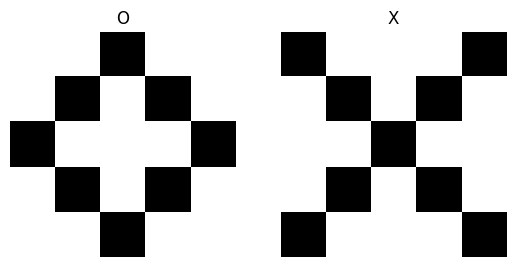

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2)

axes[0].imshow(o, cmap='Greys')
axes[0].set_title("O")
axes[0].axis("off")

axes[1].imshow(x, cmap='Greys')
axes[1].set_title("X")
axes[1].axis("off")

plt.show()

In [7]:
print(f'X:\n{X}')
print('-' * 3)
print(f'y:\n{y}')

X:
[[[0 0 1 0 0]
  [0 1 0 1 0]
  [1 0 0 0 1]
  [0 1 0 1 0]
  [0 0 1 0 0]]

 [[1 0 0 0 1]
  [0 1 0 1 0]
  [0 0 1 0 0]
  [0 1 0 1 0]
  [1 0 0 0 1]]]
---
y:
[0. 1.]


In [8]:
# cnn configs
KERNEL_SIZE = 3
N_KERNELS = 2

In [9]:
LR = 0.1

##### Como saber qual o shape de saída (Conv e Poolig)
$$out = \frac{N * (2 * P) - F}{S} + 1$$
Onde:
- *N*: Tamanho da entrada
- *F*: Tamanho do kernel
- *S*: Stride, o quanto nos deslocamos pela nossa imagem (array)
- *P*: Tamanho do Padding
A saída final será: (**out** x **out**)

##### Construção da nossa rede
- *dim da entrada*: 5x5
- *kernel size*: 2x3x3
- *saída da convolução*: $\frac{5 * (2 * 0) - 3}{1} + 1 = 3$ → *(2x3x3)* Matriz de saída
- *saída do pooling*: $\frac{3 * (2 * 0) - 2}{1} + 1 = 2$ → *(2x2x2)* Matriz de saída
- *flatten*: $2 * 2 * 2 = 8$
- *linear*: 8 → 4
- *output*: 4 → 1 

In [10]:
np.random.seed(SEED)
# inicializa os pesos com He inicialization
he_inicializarion = (
    np.random.randn(N_KERNELS, KERNEL_SIZE, KERNEL_SIZE) * 
    np.sqrt(2 / (KERNEL_SIZE * KERNEL_SIZE))
)
cnn = {
    'kernel': {
        'W': he_inicializarion,
        'b': np.zeros(N_KERNELS)
    },
    'linear': {
        'W': np.random.randn(4, 8) * np.sqrt(2 / 4),
        'b': np.zeros(4)  # (out,)
    },
    'output': {
        'W': np.random.randn(1, 4) * np.sqrt(2 / 2),
        'b': np.zeros(1)  # (out,)
    },
}

In [11]:
cnn_before = deepcopy(cnn)

In [12]:
cnn

{'kernel': {'W': array([[[ 0.2341533 , -0.06517842,  0.3053233 ],
          [ 0.71796316, -0.11038096, -0.11037322],
          [ 0.74444806,  0.3617722 , -0.22131235]],
  
         [[ 0.25576526, -0.2184572 , -0.21954711],
          [ 0.11406211, -0.90192896, -0.81313406],
          [-0.26506488, -0.47745317,  0.14813761]]]),
  'b': array([0., 0.])},
 'linear': {'W': array([[-0.64206998, -0.99864952,  1.03637018, -0.15964795,  0.04774965,
          -1.0074491 , -0.38493672,  0.07843412],
         [-0.81387536,  0.26565862, -0.42471569, -0.20625863, -0.42547083,
           1.30975846, -0.00954398, -0.74791457],
         [ 0.58162709, -0.86326682,  0.14768886, -1.38569603, -0.93916936,
           0.13920191,  0.52217473,  0.12117567],
         [-0.08177568, -0.21291246, -1.04547293, -0.50900672, -0.3257208 ,
           0.74749829,  0.24297482, -1.24665765]]),
  'b': array([0., 0., 0., 0.])},
 'output': {'W': array([[ 0.32408397, -0.38508228, -0.676922  ,  0.61167629]]),
  'b': array([0.]

In [13]:
cnn['kernel']['W']

array([[[ 0.2341533 , -0.06517842,  0.3053233 ],
        [ 0.71796316, -0.11038096, -0.11037322],
        [ 0.74444806,  0.3617722 , -0.22131235]],

       [[ 0.25576526, -0.2184572 , -0.21954711],
        [ 0.11406211, -0.90192896, -0.81313406],
        [-0.26506488, -0.47745317,  0.14813761]]])

In [14]:
def relu(z: Tensor) -> Tensor:
    return np.where(z > 0, z, 0)

def sigmoid(logits: Tensor):
  return 1 / (1 + np.exp(-logits))

In [15]:
def leaky_relu(x, a=0.01):
    return np.where(x > 0, x, a * x)

def leaky_relu_back(dout, x, a=0.01):
    return dout * np.where(x > 0, 1, a)

def bce(pred, true):
    eps = 1e-8
    return -np.mean(true * np.log(pred + eps) + (1 - true) * np.log(1 - pred + eps))

In [16]:
def conv_forward(image, W, b):
    H, Wi = image.shape
    NK, KH, KW = W.shape
    OH, OW = H - KH + 1, Wi - KW + 1
    out = np.zeros((NK, OH, OW))
    for k in range(NK):
        for i in range(OH):
            for j in range(OW):
                out[k, i, j] = np.sum(image[i:i+KH, j:j+KW] * W[k]) + b[k]
    return out  # (NK, 3, 3)

In [17]:
def conv_backward(dout, image, W):
    NK, KH, KW = W.shape
    NK, OH, OW = dout.shape
    dW = np.zeros_like(W)
    db = np.zeros(NK)
    for k in range(NK):
        db[k] = np.sum(dout[k])
        for i in range(OH):
            for j in range(OW):
                dW[k] += image[i:i+KH, j:j+KW] * dout[k, i, j]
    return dW, db

In [18]:
def maxpool_forward(x):
    NK, H, W = x.shape
    OH, OW = H - 1, W - 1
    out = np.zeros((NK, OH, OW))
    idx = {}
    for k in range(NK):
        for i in range(OH):
            for j in range(OW):
                patch = x[k, i:i+2, j:j+2]
                li = np.unravel_index(np.argmax(patch), patch.shape)
                out[k, i, j] = patch[li]
                idx[(k, i, j)] = (i + li[0], j + li[1])
    return out, idx

def maxpool_backward(dout, idx, shape):
    dx = np.zeros(shape)
    NK, OH, OW = dout.shape
    for k in range(NK):
        for i in range(OH):
            for j in range(OW):
                r, c = idx[(k, i, j)]
                dx[k, r, c] += dout[k, i, j]
    return dx

In [19]:
def forward(X, cnn):
    batch = X.shape[0]
    cache = {'X': X}

    # Conv → LeakyReLU → (batch, 2, 3, 3)
    Z_conv = np.array([conv_forward(X[i], cnn['kernel']['W'], cnn['kernel']['b']) for i in range(batch)])
    A_conv = leaky_relu(Z_conv)
    cache['Z_conv'] = Z_conv

    # MaxPool → (batch, 2, 2, 2)
    pool_outs, pool_idxs = [], []
    for i in range(batch):
        po, pidx = maxpool_forward(A_conv[i])
        pool_outs.append(po); pool_idxs.append(pidx)
    Z_pool = np.array(pool_outs)
    cache.update({'Z_pool': Z_pool, 'pool_idxs': pool_idxs, 'pool_in_shape': A_conv[0].shape})

    # Flatten → (batch, 8)
    flat = Z_pool.reshape(batch, -1)
    cache['flat'] = flat

    # Linear → LeakyReLU → (batch, 4)
    Z_lin = flat @ cnn['linear']['W'].T + cnn['linear']['b']
    A_lin = leaky_relu(Z_lin)
    cache['Z_lin'] = Z_lin; cache['A_lin'] = A_lin

    # Output → Sigmoid → (batch,)
    Z_out = A_lin @ cnn['output']['W'].T + cnn['output']['b']
    A_out = sigmoid(Z_out).flatten()
    cache['A_out'] = A_out

    return A_out, cache

In [20]:
def backward(y_true, cache, cnn, lr=LR):
    batch = y_true.shape[0]

    # BCE + Sigmoid: dL/dZ = (pred - y) / batch
    dZ_out = ((cache['A_out'] - y_true) / batch).reshape(-1, 1)

    dW_out = dZ_out.T @ cache['A_lin']           # (1, 4)
    db_out = np.sum(dZ_out, axis=0)
    dA_lin = dZ_out @ cnn['output']['W']          # (batch, 4)

    dZ_lin = leaky_relu_back(dA_lin, cache['Z_lin'])
    dW_lin = dZ_lin.T @ cache['flat']             # (4, 8)
    db_lin = np.sum(dZ_lin, axis=0)
    dflat  = dZ_lin @ cnn['linear']['W']          # (batch, 8)

    dpool  = dflat.reshape(cache['Z_pool'].shape)
    dA_conv = np.array([
        maxpool_backward(dpool[i], cache['pool_idxs'][i], cache['pool_in_shape'])
        for i in range(batch)
    ])

    dZ_conv = leaky_relu_back(dA_conv, cache['Z_conv'])
    dW_k = np.zeros_like(cnn['kernel']['W'])
    db_k = np.zeros_like(cnn['kernel']['b'])
    for i in range(batch):
        dw, db = conv_backward(dZ_conv[i], cache['X'][i], cnn['kernel']['W'])
        dW_k += dw; db_k += db

    # Gradient descent
    cnn['output']['W'] -= lr * dW_out
    cnn['output']['b'] -= lr * db_out
    cnn['linear']['W'] -= lr * dW_lin
    cnn['linear']['b'] -= lr * db_lin
    cnn['kernel']['W'] -= lr * dW_k
    cnn['kernel']['b'] -= lr * db_k
    return cnn

In [21]:
for epoch in range(10_000):
    pred, cache = forward(X, cnn)
    loss = bce(pred, y)
    cnn = backward(y, cache, cnn, lr=0.1)
    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:>6d} | "
            f"Loss: {loss:>10.6f} | "
            f"O: {pred[0]:>8.4f} | "
            f"X: {pred[1]:>8.4f}"
        )

Epoch      0 | Loss:   0.693072 | O:   0.5003 | X:   0.5004
Epoch    500 | Loss:   0.691611 | O:   0.4993 | X:   0.5008
Epoch   1000 | Loss:   0.686245 | O:   0.4966 | X:   0.5036
Epoch   1500 | Loss:   0.038547 | O:   0.0017 | X:   0.9274
Epoch   2000 | Loss:   0.013629 | O:   0.0004 | X:   0.9735
Epoch   2500 | Loss:   0.008179 | O:   0.0002 | X:   0.9840
Epoch   3000 | Loss:   0.005825 | O:   0.0001 | X:   0.9886
Epoch   3500 | Loss:   0.004517 | O:   0.0001 | X:   0.9911
Epoch   4000 | Loss:   0.003686 | O:   0.0001 | X:   0.9927
Epoch   4500 | Loss:   0.003112 | O:   0.0001 | X:   0.9939
Epoch   5000 | Loss:   0.002692 | O:   0.0001 | X:   0.9947
Epoch   5500 | Loss:   0.002371 | O:   0.0000 | X:   0.9953
Epoch   6000 | Loss:   0.002118 | O:   0.0000 | X:   0.9958
Epoch   6500 | Loss:   0.001914 | O:   0.0000 | X:   0.9962
Epoch   7000 | Loss:   0.001746 | O:   0.0000 | X:   0.9965
Epoch   7500 | Loss:   0.001604 | O:   0.0000 | X:   0.9968
Epoch   8000 | Loss:   0.001484 | O:   0

In [22]:
cnn_before

{'kernel': {'W': array([[[ 0.2341533 , -0.06517842,  0.3053233 ],
          [ 0.71796316, -0.11038096, -0.11037322],
          [ 0.74444806,  0.3617722 , -0.22131235]],
  
         [[ 0.25576526, -0.2184572 , -0.21954711],
          [ 0.11406211, -0.90192896, -0.81313406],
          [-0.26506488, -0.47745317,  0.14813761]]]),
  'b': array([0., 0.])},
 'linear': {'W': array([[-0.64206998, -0.99864952,  1.03637018, -0.15964795,  0.04774965,
          -1.0074491 , -0.38493672,  0.07843412],
         [-0.81387536,  0.26565862, -0.42471569, -0.20625863, -0.42547083,
           1.30975846, -0.00954398, -0.74791457],
         [ 0.58162709, -0.86326682,  0.14768886, -1.38569603, -0.93916936,
           0.13920191,  0.52217473,  0.12117567],
         [-0.08177568, -0.21291246, -1.04547293, -0.50900672, -0.3257208 ,
           0.74749829,  0.24297482, -1.24665765]]),
  'b': array([0., 0., 0., 0.])},
 'output': {'W': array([[ 0.32408397, -0.38508228, -0.676922  ,  0.61167629]]),
  'b': array([0.]

In [23]:
cnn

{'kernel': {'W': array([[[ 0.09509511,  0.95087919,  0.01580585],
          [ 0.95088866, -0.26527555, -1.69629963],
          [ 0.45493061,  0.95087873, -0.36037053]],
  
         [[ 0.25735803, -0.22076192, -0.21842991],
          [ 0.11175739, -0.90145338, -0.81466067],
          [-0.26394768, -0.47823129,  0.14973039]]]),
  'b': array([-0.20546304, -0.00071195])},
 'linear': {'W': array([[-0.65520251, -0.98468026,  1.01215151, -0.15122184,  0.04747924,
          -1.00777627, -0.38548151,  0.07816371],
         [-0.77508132,  0.19312946, -0.37004815, -0.27034456, -0.42500404,
           1.31032223, -0.00861347, -0.74744778],
         [ 1.5201333 , -1.17626961,  1.12905668, -1.65451788, -0.93789936,
           0.1407941 ,  0.52496758,  0.12244567],
         [-0.17448108, -0.00694671, -1.17208122, -0.32342926, -0.32676768,
           0.74623486,  0.24089898, -1.24770453]]),
  'b': array([-0.00169198, -0.01179048,  0.30911582,  0.04260776])},
 'output': {'W': array([[-0.20810561, -0.20

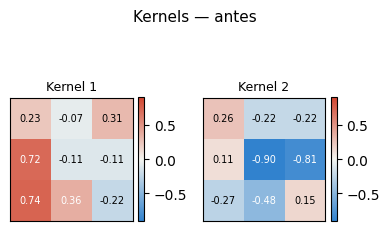

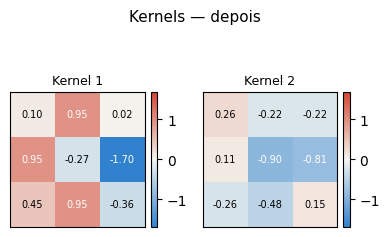

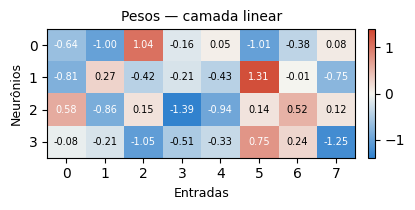

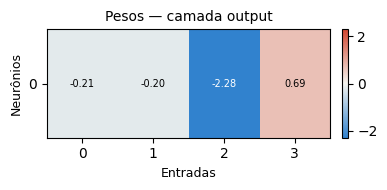

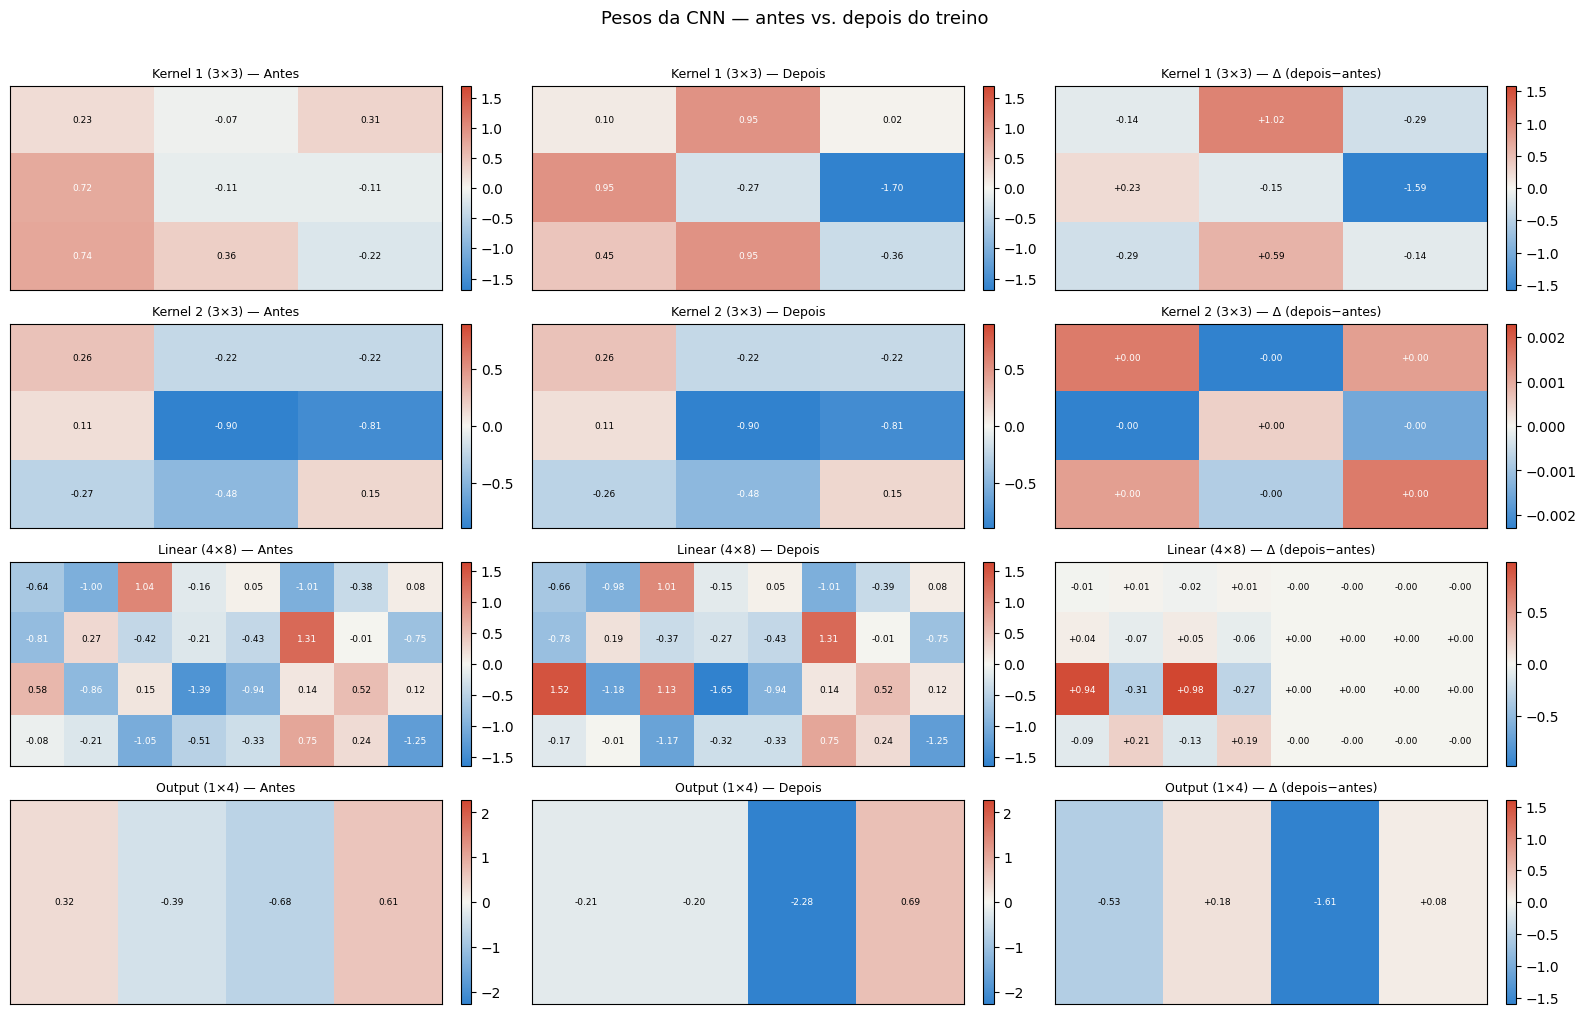

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec


def _make_cmap():
    """Azul → branco → vermelho, igual ao widget."""
    colors = ["#3182CE", "#F5F5F0", "#D14630"]
    return mcolors.LinearSegmentedColormap.from_list("bwr_custom", colors)


def plot_kernels(cnn: dict, title: str = "Kernels convolucionais", ax_size: float = 2.0):
    """
    Plota os kernels convolucionais como heatmaps.

    Parâmetros
    ----------
    cnn     : dicionário com chave 'kernel' → {'W': array (N, KH, KW), 'b': array (N,)}
    title   : título geral da figura
    ax_size : tamanho de cada subplot em polegadas
    """
    W = np.array(cnn["kernel"]["W"])   # (N_kernels, KH, KW)
    N = W.shape[0]
    cmap = _make_cmap()
    vmax = np.abs(W).max()

    fig, axes = plt.subplots(1, N, figsize=(ax_size * N, ax_size + 0.6))
    if N == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        im = ax.imshow(W[i], cmap=cmap, vmin=-vmax, vmax=vmax, aspect="equal")
        for r in range(W[i].shape[0]):
            for c in range(W[i].shape[1]):
                ax.text(c, r, f"{W[i][r,c]:.2f}", ha="center", va="center",
                        fontsize=7, color="white" if abs(W[i][r,c]) > vmax*0.4 else "black")
        ax.set_title(f"Kernel {i+1}", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(title, fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_weights(cnn: dict, layer: str, title: str = None, figsize: tuple = None):
    """
    Plota os pesos de uma camada ('linear' ou 'output') como heatmap.

    Parâmetros
    ----------
    cnn   : dicionário da CNN
    layer : 'linear' ou 'output'
    title : título opcional
    """
    W = np.array(cnn[layer]["W"])
    cmap = _make_cmap()
    vmax = np.abs(W).max()
    rows, cols = W.shape

    if figsize is None:
        figsize = (max(cols * 0.55, 4), max(rows * 0.55, 2))

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(W, cmap=cmap, vmin=-vmax, vmax=vmax, aspect="auto")

    for r in range(rows):
        for c in range(cols):
            ax.text(c, r, f"{W[r,c]:.2f}", ha="center", va="center",
                    fontsize=7, color="white" if abs(W[r,c]) > vmax*0.4 else "black")

    ax.set_xlabel("Entradas", fontsize=9)
    ax.set_ylabel("Neurônios", fontsize=9)
    ax.set_title(title or f"Pesos — camada {layer}", fontsize=10)
    ax.set_xticks(range(cols)); ax.set_yticks(range(rows))
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
    plt.tight_layout()
    plt.show()


def plot_cnn_comparison(cnn_before: dict, cnn_after: dict, figsize: tuple = (16, 10)):
    """
    Compara TODOS os pesos (kernels + linear + output) antes e depois do treino.

    Parâmetros
    ----------
    cnn_before : dicionário da CNN antes do treino
    cnn_after  : dicionário da CNN depois do treino
    figsize    : tamanho total da figura
    """
    cmap = _make_cmap()

    def flat_weights(cnn):
        """Retorna lista de (label, matriz 2D) para todos os layers."""
        layers = []
        W_k = np.array(cnn["kernel"]["W"])
        for i in range(W_k.shape[0]):
            layers.append((f"Kernel {i+1} (3×3)", W_k[i]))
        layers.append(("Linear (4×8)", np.array(cnn["linear"]["W"])))
        layers.append(("Output (1×4)", np.array(cnn["output"]["W"])))
        return layers

    before = flat_weights(cnn_before)
    after  = flat_weights(cnn_after)
    n = len(before)

    fig, axes = plt.subplots(n, 3, figsize=figsize,
                             gridspec_kw={"width_ratios": [1, 1, 1]})
    fig.suptitle("Pesos da CNN — antes vs. depois do treino", fontsize=13, y=1.01)

    for i, ((lbl, Wb), (_, Wa)) in enumerate(zip(before, after)):
        vmax = max(np.abs(Wb).max(), np.abs(Wa).max())

        for col, (W, subtitle) in enumerate([(Wb, "Antes"), (Wa, "Depois")]):
            ax = axes[i, col]
            im = ax.imshow(W, cmap=cmap, vmin=-vmax, vmax=vmax, aspect="auto")
            for r in range(W.shape[0]):
                for c in range(W.shape[1]):
                    ax.text(c, r, f"{W[r,c]:.2f}", ha="center", va="center",
                            fontsize=6.5, color="white" if abs(W[r,c]) > vmax*0.4 else "black")
            ax.set_title(f"{lbl} — {subtitle}", fontsize=9)
            ax.set_xticks([]); ax.set_yticks([])
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # Coluna 3: diferença (depois - antes)
        ax_diff = axes[i, 2]
        diff = Wa - Wb
        vd = np.abs(diff).max() or 1e-8
        im_d = ax_diff.imshow(diff, cmap=cmap, vmin=-vd, vmax=vd, aspect="auto")
        for r in range(diff.shape[0]):
            for c in range(diff.shape[1]):
                ax_diff.text(c, r, f"{diff[r,c]:+.2f}", ha="center", va="center",
                             fontsize=6.5, color="white" if abs(diff[r,c]) > vd*0.4 else "black")
        ax_diff.set_title(f"{lbl} — Δ (depois−antes)", fontsize=9)
        ax_diff.set_xticks([]); ax_diff.set_yticks([])
        plt.colorbar(im_d, ax=ax_diff, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


# ── Uso ──────────────────────────────────────────────────────
plot_kernels(cnn_before, title="Kernels — antes")
plot_kernels(cnn,  title="Kernels — depois")
plot_weights(cnn_before, layer="linear")
plot_weights(cnn,  layer="output")
plot_cnn_comparison(cnn_before, cnn)